In [36]:
from pathlib import Path
import sys

%load_ext autoreload
%reload_ext autoreload
%autoreload 2

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "NeuralNetwork" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import itertools


from src.data_utils import (
    load_data,
    df_to_tensors,
    signed_log1p,
    log_output,
    scale_input,
    oversample_high_values,
    split_tensors,
    get_kfold_splits,
    create_dataloaders,
)
from src.engine import set_seed, find_lr, train_model, cross_validate_model
from src.model import build_model
from src.testing import evaluate_regression
from src.visualization import plot_predicted_vs_observed

from tqdm.autonotebook import tqdm

set_seed(18)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [38]:
data = load_data(str(ROOT / "data" / "features.csv"))
TARGET_COL = 'dens'

x_raw, y_raw = df_to_tensors(data, TARGET_COL)

X_train, y_train, X_test, y_test = split_tensors(x_raw, y_raw, test_size=0.2, seed=42)

# X_train, y_train = oversample_high_values(
#         X_train, y_train,
#         threshold=OVERSAMPLE_THRESHOLD,
#         repeat_factor=OVERSAMPLE_FACTOR
# )

X_train = signed_log1p(X_train)
X_test = signed_log1p(X_test)

X_train_scaled, X_test_scaled, _ = scale_input(X_train, X_test)

y_train_log = log_output(y_train)
y_test_log   = log_output(y_test)

train_loader = create_dataloaders(X_train_scaled, y_train_log, batch_size=64, shuffle=True)
test_loader   = create_dataloaders(X_test_scaled,   y_test_log,   batch_size=64)

  0%|          | 0/200 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
iteration: 200
Search range: 1.0e-04 -> 1.0e+00
Suggested LR (bằng tính toán): 3.87E-03
LR suggestion: steepest gradient
Suggested LR: 3.87E-03


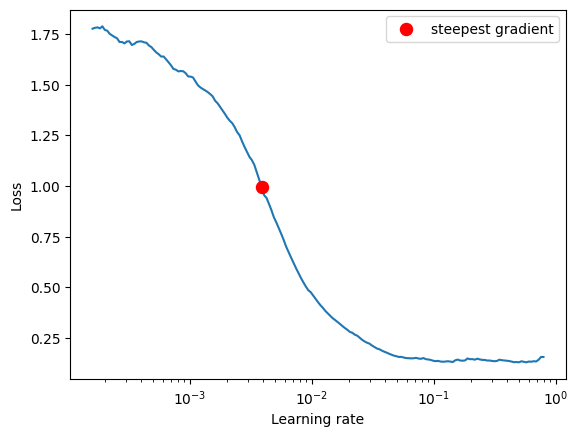

In [39]:
best_learning_rate = find_lr(
    model_builder=build_model, 
    train_loader=train_loader,
)

In [40]:
param_grid = {
    'lr': [best_learning_rate],
    # 'oversample_threshold': [100, 150],
    # 'oversample_factor': [10, 15],
    'BATCH_SIZE': [64],
    "loss_func" : [
        nn.HuberLoss(delta=0.1),               # Tương tự SmoothL1 nhưng ổn định hơn
        nn.HuberLoss(delta=0.2),
        nn.HuberLoss(delta=0.5),               # Tương tự SmoothL1 nhưng ổn định hơn
        nn.HuberLoss(delta=1.0),
        nn.HuberLoss(delta=2),               # Tương tự SmoothL1 nhưng ổn định hơn
        nn.HuberLoss(delta=5),
    ],
}

keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

results = []
best_pct_rmse = float('inf') 
best_params = None

for idx, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    print(f"[{idx + 1}/{len(combinations)}] Testing Params: {params}")

    fold_metrics = cross_validate_model(
        model_builder=build_model, 
        x_train=X_train, 
        y_train=y_train,
        n_splits=3,       
        epochs=10,         
        batch_size=params['BATCH_SIZE'],
        lr=params['lr'],
        # oversample_threshold=params['oversample_threshold'],
        # oversample_factor=params['oversample_factor'],
        loss_func=params['loss_func'],
        verbose=False      
    )

    # Kết quả từng fold
    for fold_idx, metrics in enumerate(fold_metrics):
        rmse, mae, pct_rmse = metrics
        print(f"  Fold {fold_idx + 1}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | %RMSE = {pct_rmse:.2f}%")

    # Kết quả của 1 bộ tham số
    avg_metrics = np.nanmean(np.array(fold_metrics), axis=0)
    avg_rmse, avg_mae, avg_pct_rmse = avg_metrics[0], avg_metrics[1], avg_metrics[2]
    
    print(f"  Average: RMSE = {avg_rmse:.4f} | MAE = {avg_mae:.4f} | %RMSE = {avg_pct_rmse:.2f}%")

    params['avg_pct_rmse'] = avg_pct_rmse
    results.append(params)

    if avg_pct_rmse < best_pct_rmse:
        best_pct_rmse = avg_pct_rmse
        best_params = params.copy() 

print(f"bộ tham số tốt nhất: {best_params}")

[1/6] Testing Params: {'lr': 0.003872038781812555, 'BATCH_SIZE': 64, 'loss_func': HuberLoss()}
  Fold 1: RMSE = 55.0782 | MAE = 7.2544 | %RMSE = 282.66%
  Fold 2: RMSE = 60.2521 | MAE = 8.8368 | %RMSE = 274.19%
  Fold 3: RMSE = 105.3057 | MAE = 9.8245 | %RMSE = 484.56%
  Average: RMSE = 73.5453 | MAE = 8.6386 | %RMSE = 347.13%
[2/6] Testing Params: {'lr': 0.003872038781812555, 'BATCH_SIZE': 64, 'loss_func': HuberLoss()}
  Fold 1: RMSE = 54.3421 | MAE = 8.0442 | %RMSE = 278.88%
  Fold 2: RMSE = 60.4520 | MAE = 8.8877 | %RMSE = 275.10%
  Fold 3: RMSE = 103.9889 | MAE = 9.8776 | %RMSE = 478.50%
  Average: RMSE = 72.9277 | MAE = 8.9365 | %RMSE = 344.16%
[3/6] Testing Params: {'lr': 0.003872038781812555, 'BATCH_SIZE': 64, 'loss_func': HuberLoss()}
  Fold 1: RMSE = 54.2856 | MAE = 7.3976 | %RMSE = 278.59%
  Fold 2: RMSE = 56.1902 | MAE = 8.2122 | %RMSE = 255.70%
  Fold 3: RMSE = 105.2708 | MAE = 9.5439 | %RMSE = 484.40%
  Average: RMSE = 71.9155 | MAE = 8.3845 | %RMSE = 339.56%
[4/6] Testing